# Análisis Exploratorio de Datos (EDA)


Para obtener el conjunto de datos completo de las estadísticas en el sector agrícola fueron descargados los datasets correspondientes desde el año 2010 hasta el 2014. Para trabajar con la información completa se concatenaron todos estos datos.

Es importante mencionar que durante la concatenación de estos datos, algunos años cambiaban el nombre de las columnas, como por ejemplo Precio que llego a registrarse como Preciomediorural. Para esto se unificaron estos nombres, que representan la misma información pero el sistema manejaba terminologías distintas.

In [1]:
#| echo: false
#| output: false
import sys
sys.path.insert(0, '..')

from src.data_loader import DataLoader
from src.eda import EDAAnalyzer

RUTA_CSV = '../data/raw/siap_2010_2024.csv'

loader = DataLoader(RUTA_CSV)
df = loader.cargar()

[DataLoader] Cargando siap_2010_2024.csv ...


[DataLoader] 541839 filas , 24 columnas cargadas.


## Descripción general

El conjunto de datos que se utiliza en este proyecto consiste de 541,839 filas correspondientes a cada registro a nivel municipal. Cada registro cuenta con 24 columnas que describen los detalles del mismo, estas son variables categóricas y numéricas.

In [2]:
#| echo: false
eda = EDAAnalyzer(df, guardar_figuras=True)
resumen = eda.descripcion_general()

DESCRIPCIÓN DEL DATASET

Filas    : 541839
Columnas : 24
Periodo  : 2010 – 2024



,Tipo de Dato,No Nulos,Únicos
Anio,Int64,541839,15
Idestado,int64,541839,32
Nomestado,category,541839,33
Idddr,int64,541839,191
Nomddr,str,541839,191
Idcader,int64,541839,19
Nomcader,str,541839,678
Idmunicipio,int64,541839,570
Nommunicipio,str,541839,2312
Idciclo,int64,541839,3


### Variable Derivada: Proporción de Siniestro

A partir de la información obtenida a través del dataset realizamos la creación de una nueva variable: Proporción de Siniestro. Esto debido a que la columna Siniestrada registra las hectáreas de la superficie de la cual no se obtuvo cultivo debido a alguna causa de fuerza mayor como lo es el impacto del cambio climático. Sin embargo, podemos diferenciar en que perder 500 hectáreas en un municipio que sembró 600 representa una catástrofe agrícola, mientras que la misma cifra en un municipio que sembó 50,000 hectáreas constituye una pérdida marginal.

Por ello, este ratio nos permite tener más consistencia de análisis y dimensionar mejor. El rango va de 0 (sin pérdida) a 1 (la totalidad del área sembrada fue siniestrada). La definición de la variable es:

$$proporcion\_siniestro = \frac{Siniestrada}{Sembrada}$$

In [3]:
#| echo: false
df = eda.nueva_variable_proporcion_siniestro()

,Tipo de Dato,No Nulos,Únicos
0,float64,541839,13328


Como resultado obtenemos la asignación de esta nueva variable para los registros, tenemos asignada esta proporción para los 541,839 datos.

Para facilitar el análisis de esta variable, la variable continua proporcion_siniestro se discretiza en 5 niveles de riesgo agrícola.

- Sin siniestro (= 0): ninguna pérdida registrada

- Riesgo bajo (0–10%): pérdida marginal, sin impacto productivo relevante

- Riesgo medio (10–40%): pérdida moderada con reducción de rendimiento

- Riesgo alto (40–75%): pérdida severa que compromete el ciclo

- Pérdida crítica (>75%): pérdida casi total del área sembrada

,Registros,% del total
nivel_riesgo,,
Sin siniestro,515022,95.05
Riesgo bajo,7072,1.31
Riesgo medio,8475,1.56
Riesgo alto,5197,0.96
Pérdida crítica,6073,1.12


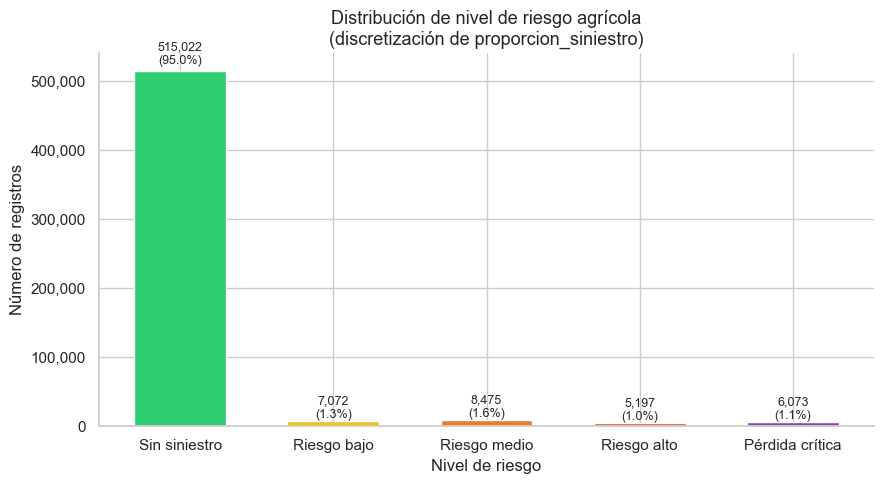

In [4]:
#| echo: false
df = eda.discretizar_proporcion_siniestro()

A partir de la distribución de esta variable observamos un desbalance muy grande, pues de las categorías definidas, 'Sin siniestro' es la que domina en el conjunto de datos. Esta categoría acumula la mayor parte de la información, lo que resalta el hecho de que si queremos predecir si ocurrirá un siniestro en un cultivo debemos balancear las clases para tener mejores resultados y no sesgar el modelo al entrenarlo.

## Calidad de datos

A continuación vamos a analizar los valores faltantes en el dataset y la presencia de registros duplicados.

In [5]:
#| echo: false
metricas_calidad = eda.calidad_datos()

,Nulos,% Nulos
Precio,487,0.09
Rendimiento,487,0.09
Volumenproduccion,1,0.00
Sembrada,2,0.00



Registros duplicados: 10


Podemos observar que la calidad de los datos proporcionados por la Dirección General del Sistema de Información Agroalimentaria y Pesquera es consistente. La presencia de datos nulos para Precio y Rendimiento se encuentra en solo 487 registros, lo que representa un 0.09% de nuestro conjunto de datos. Estos registros son una pequeña proporción, dado que contamos con más de 500,000 datos resulta muy pequeña la cantidad de nulos.

Por otro lado, Volumenproduccion y Sembrada en conjunto presentan nulos en tan solo 3 registros, lo cual no afecta en la potencia estadística.

### Valores Faltantes

Resulta conveniente adentrarnos en la aparición de valores nulos en ciertos registros. En el siguiente gráfico podemos ver la correlación entre la presencia de nulos de las 4 variables que los presentan: Sembrada, Volumenproduccion, Rendimiento y Precio.

Podemos observar que Rendimiento y Precio están fuertemente relacionadas. En 487 registros, Precio y Rendimiento faltan en conjunto, es decir, cuando falta Precio siempre falta Rendimiento, lo que indica una regla o dependencia estricta. Por otro lado, Sembrada y Volumenproduccion al ser muy pocos pueden ser considerados como errores de captura en el sistema de datos que obtuvimos inicialmente.

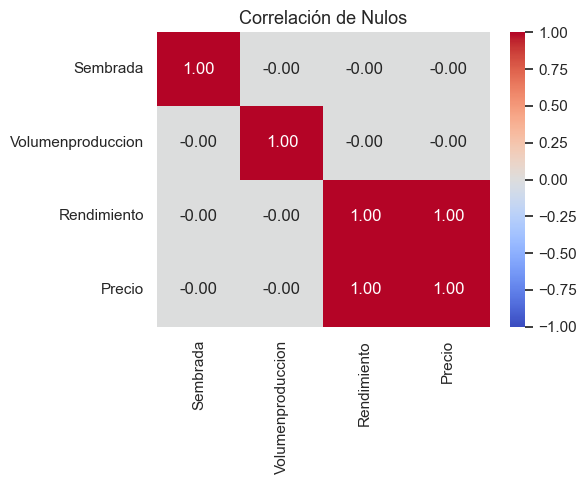

In [6]:
#| echo: false
eda.analisis_nulos()

Adentrandonos más en la falta de los campos Precio y Rendimiento totalmente relacionados, conviene analizar si son un error de captura en el sistema indicando MCAR o si hay algún factor que influye en su ausencia. 

In [7]:
#| echo: false
nulos_precio = df['Precio'].isna()
cosechada_cero = df['Cosechada'] == 0
total_nulos = nulos_precio.sum()

if total_nulos > 0:
    coincidencias = (nulos_precio & cosechada_cero).sum()
    pct = (coincidencias / total_nulos) * 100
                
    print(f"De los {total_nulos:,} registros sin Precio/Rendimiento,")
    print(f"{coincidencias:,} ({pct:.2f}%) tienen Área Cosechada igual a 0.")

De los 487 registros sin Precio/Rendimiento,
487 (100.00%) tienen Área Cosechada igual a 0.


Al filtrar los datos por los registros con nulos en Precio y al compararlo con la columna de Cosechada, observamos que todos los registros que les falta el Precio/Rendimiento presentan un área cosechada de 0.

Si un cultivo se siembra pero hay una sequía o inundación y se pierde todo (Área Cosechada = 0), entonces el Volumen de Producción será 0. Dado que el Rendimiento se calcula dividiendo la producción entre el área cosechada, el valor no existe (se vuelve nulo). Y como no se produjo nada, no hay producto que vender, por lo tanto no se reporta un Precio. En este caso, la falta de datos es estructural y depende del área cosechada/siniestrada (esto lo clasifica como MAR, ya que la ausencia se explica por otra variable observable).

**Deciciones sobre Valores Faltantes**

Con las observaciones anteriores, procedemos con los datos como sigue:

1. Se eliminan los registros que tienen valores nulos en Sembrada y Volumenproduccion, debido a que indican presencia de errores de captura.

2. Para los 487 registros donde falta Precio/Rendimiento, se actualizan los campos correspondientes a 0 (cero), debido a que comprobamos que pudo haber sido error de captura cuando el área cosechada fue 0.

In [8]:
#| echo: false
df = eda.imputar_nulos_estructurales()

### Duplicados

En el total del conjunto de datos se encontraron únicamente 10 registros duplicados. Dado que es un número muy pequeño considerando el tamaño de datos que estamos trabajando, podemos eliminarlos sin afectar la potencia estadística.

In [9]:
#| echo: false
df = eda.eliminar_duplicados()

Se eliminaron 10 registros duplicados.
El dataset ahora tiene 541,829 filas.


Como resultado de esta decisión, ahora el dataset cuenta con 541,829 registros.

## Estadísticas descriptivas

A continuación presentamos las estadísticas descriptivas de nuestro conjunto de datos. Necesitamos analizar tanto nuestras variables numéricas como las categóricas.

### Variables Numéricas

In [10]:
#| echo: false
desc = eda.estadisticas_descriptivas_numericas()

,count,mean,std,min,25%,50%,75%,max,rango
Sembrada,541827.0,5.807369e+02,2.640830e+03,0.0,10.00,39.40,2.160000e+02,2.165483e+05,2.165483e+05
Cosechada,541829.0,5.442921e+02,2.535063e+03,0.0,9.00,35.00,2.000000e+02,2.165483e+05,2.165483e+05
Siniestrada,541829.0,2.413520e+01,3.866740e+02,0.0,0.00,0.00,0.000000e+00,5.407300e+04,5.407300e+04
Volumenproduccion,541828.0,1.619187e+04,6.179774e+05,0.0,52.40,292.50,1.743753e+03,1.183000e+08,1.183000e+08
Rendimiento,541829.0,1.091273e+03,6.211413e+04,0.0,2.07,7.91,2.000000e+01,1.059804e+07,1.059804e+07
Precio,541829.0,6.783825e+03,1.171066e+04,0.0,2217.22,4298.52,7.675000e+03,2.048000e+06,2.048000e+06
Valorproduccion,541829.0,1.617641e+07,9.034843e+07,0.0,246245.25,1084183.48,5.443200e+06,7.622198e+09,7.622198e+09


El análisis descriptivo de las variables numéricas revela patrones relevantes sobre la estructura productiva y la distribución del riesgo agrícola en México durante el periodo 2010–2024.

**Área sembrada y cosechada** presentan distribuciones muy similares entre sí, lo cual es esperado dado que la mayor parte de lo sembrado logra cosecharse en condiciones normales. Ambas variables tienen una media considerablemente mayor a su mediana (Sembrada: media = 580.7 ha, mediana = 39.4 ha; Cosechada: media = 544.3 ha, mediana = 35.0 ha), lo que indica una distribución fuertemente sesgada hacia la derecha. Esto refleja la coexistencia de pequeños productores con superficies mínimas junto a grandes unidades productivas que elevan la media. El valor máximo de 216,548 ha confirma la presencia de registros de gran escala que actúan como outliers en la distribución.

La media de **Área siniestrada** es de apenas 24.1 ha, pero su desviación estándar es de 386.7 ha, casi 16 veces mayor que la media, lo que evidencia una dispersión extrema. Más revelador aún es que tanto el percentil 25 como el percentil 50 y el percentil 75 son iguales a 0, lo que significa que al menos el 75% de los registros no reportaron ningún siniestro. La pérdida agrícola es entonces un evento infrecuente pero de alta magnitud cuando ocurre, con un máximo registrado de 54,073 ha en un solo registro.

Por otro lado, **Rendimiento** presenta la mayor dispersión relativa de todas las variables, con una desviación estándar de 62,114 sobre una media de 1,091 ton/ha, y un máximo de 10,598,037. La unidad de medida son toneladas por hectárea, con excepción de los cultivos que tienen otra métrica la cual se señala en el nombre del cultivo (gruesa, manojo, planta, entre otros). Por lo que los valores extremos pueden corresponder a estas medidas distintas.

**Precio** y **Valorproduccion** muestran rangos enormes (precio máximo de 2,048,000 pesos por tonelada), consistentes con la diversidad de cultivos registrados, desde granos básicos de bajo valor unitario hasta productos especializados de alto valor. Para el Precio encontramos que el valor mínimo corresponde a 0, pues puede ser que no se haya cosechado nada o que los cultivos sean de autoconsumo y no registra precio comercial.

### Variables Categóricas

In [11]:
#| echo: false
eda.estadisticas_descriptivas_categoricas()


Nomestado: 33 categorías. Moda: 'Oaxaca'
Top 3 frecuencias:
- Oaxaca: 71,184 registros
- Puebla: 51,753 registros
- Michoacán: 35,188 registros

Nomcicloproductivo: 3 categorías. Moda: 'Primavera-Verano'
Top 3 frecuencias:
- Primavera-Verano: 234,707 registros
- Perennes: 166,175 registros
- Otoño-Invierno: 140,947 registros

Nommodalidad: 2 categorías. Moda: 'Riego'
Top 3 frecuencias:
- Riego: 295,546 registros
- Temporal: 246,283 registros

Nomcultivo: 454 categorías. Moda: 'Maíz grano'
Top 3 frecuencias:
- Maíz grano: 69,586 registros
- Frijol: 43,677 registros
- Avena forrajera en verde: 21,910 registros


**Nomestado** registra 33 categorías con moda en Oaxaca con 71,184 registros, lo que indica que este estado concentra la mayor cantidad de registros en el dataset. Esto es consistente con su alta diversidad municipal (es el estado con más municipios en México, 570) y con la variedad de cultivos que se producen en su territorio. No implica necesariamente que Oaxaca tenga el mayor volumen productivo, sino que tiene la mayor cantidad de combinaciones únicas de año-municipio-cultivo registradas. Sin embargo, el estado tiene una importante producción agrícola, en su territorio se siembra: maíz, frijol, cacahuate, trigo, sorgo, café, limón, mango, maguey mezcalero (que es la bebida tradicional de la región), copra y hule, siendo éstos los cultivos más representativos. Además cuenta con frutales que le han dado fama a Oaxaca, por ejemplo la piña de Loma Bonita y el chicozapote de la región de la Cañada.

**Nomcicloproductivo** tiene 3 categorías con moda en Primavera-Verano, el ciclo agrícola principal en México. Este ciclo concentra la mayoría de la actividad de temporal, que depende de las lluvias estacionales y es por tanto el más expuesto al riesgo climático. Su predominancia en el dataset es relevante para el análisis de siniestros, ya que las sequías e inundaciones afectan principalmente este ciclo. Las categorías para el ciclo productivo son: *Primavera-Verano*, *Otoño-Invierno* y *Perennes*. La que tiene menos frecuencia es Otoño-Invierno, lo que puede deberse a las dificultades climáticas de la temporada para ciertos cultivos.

**Nommodalidad** presenta únicamente 2 categorías (Riego y Temporal), con moda en Riego. Aunque en la realidad nacional la agricultura de temporal supera en superficie a la de riego, el mayor número de registros bajo modalidad de riego puede explicarse por la mayor diversidad de cultivos que se producen bajo esta modalidad y su distribución en más municipios. Esta variable es una de las más importantes para el análisis de vulnerabilidad, dado que las siembras de temporal son estructuralmente más susceptibles al siniestro por su dependencia de las precipitaciones.

**Nomcultivo** es la variable categórica con mayor cardinalidad, con 454 categorías distintas y moda en Maíz grano. La dominancia del maíz es consistente con su rol como cultivo básico de México: es el de mayor superficie sembrada, el más distribuido geográficamente y el de mayor relevancia para la seguridad alimentaria nacional.A nivel mundial, México es el 7° productor de este grano.

## Detección de valores atípicos

Para la identificación de valores atípicos se aplicó la regla IQR, que define como outlier cualquier valor que se encuentre por debajo de $Q1 - 1.5 \times IQR$ o por encima de $Q3 + 1.5 \times IQR$. Los resultados se complementan con boxplots comparativos por modalidad hídrica (Temporal vs. Riego).

Se decidió agrupar los boxplots por modalidad hídrica ("Riego" vs "Temporal") en lugar de hacerlo de manera general debido a que tienen perfiles y escalas muy diferentes.

1. Diferencias de rendimiento y producción: Las tierras de "Riego" suelen tener un control mucho mayor sobre el agua, lo que resulta en rendimientos más altos y estables. Las de "Temporal" dependen completamente del clima (lluvias), por lo que suelen tener rendimientos más bajos y mayor variabilidad. Un valor de rendimiento que es "normal" para Riego podría ser un "valor atípico (excesivamente alto)" para Temporal.

2. Diferencias en siniestros: Las tierras de Temporal son estructuralmente más vulnerables a las sequías o excesos de lluvia. Si mezclas ambos, el alto nivel de siniestros normal en Temporal podría parecer un "outlier" general, o viceversa, la falta de siniestros en Riego podría sesgar la media.

In [12]:
#| echo: false
tabla_outliers = eda.detectar_outliers()

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
Variable,,,,,,,
Sembrada,10.00,2.160000e+02,2.060000e+02,-2.990000e+02,5.250000e+02,86182,15.91
Cosechada,9.00,2.000000e+02,1.910000e+02,-2.775000e+02,4.865000e+02,86336,15.93
Siniestrada,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,26817,4.95
Volumenproduccion,52.40,1.743753e+03,1.691352e+03,-2.484629e+03,4.280781e+03,85197,15.72
Rendimiento,2.07,2.000000e+01,1.793000e+01,-2.482500e+01,4.689500e+01,48834,9.01
Precio,2217.22,7.675000e+03,5.457780e+03,-5.969450e+03,1.586167e+04,39129,7.22
Valorproduccion,246245.25,5.443200e+06,5.196955e+06,-7.549187e+06,1.323863e+07,81976,15.13


### Área Sembrada y Cosechada

| Área Sembrada | Área Cosechada |
| :---: | :---: |
| <img src="figuras/outliers_boxplot_Sembrada.png" width="400"> | <img src="figuras/outliers_boxplot_Cosechada.png" width="400"> |

Ambas variables presentan un porcentaje de outliers elevado y prácticamente idéntico (15.91% y 15.93% respectivamente), con límites superiores de 525 ha y 486.5 ha. Los valores que superan estos umbrales corresponden a grandes unidades productivas en entidades donde la agricultura comercial a gran escala es predominante. En los boxplots se observa que la modalidad Temporal concentra los outliers de mayor magnitud absoluta, alcanzando valores cercanos a las 200,000 ha, mientras que Riego presenta outliers más acotados pero igualmente presentes. Esta asimetría refleja que las grandes superficies de temporal corresponden a regiones donde un solo registro puede representar miles de hectáreas de un solo cultivo en un municipio.

> Estos outliers no se eliminan. Representan realidades productivas legítimas y su exclusión sesgaría el análisis hacia pequeños productores, perdiendo información crítica sobre las regiones de mayor impacto en la seguridad alimentaria nacional. En el modelado se deberá reducir la influencia de estos valores extremos sin descartarlos.

### Área Siniestrada

<img src="figuras/outliers_boxplot_Siniestrada.png" width="300">

Siniestrada presenta una situación estadísticamente particular: tanto Q1, Q3 como el IQR son iguales a cero, lo que resulta en límites inferior y superior de exactamente 0. Bajo la regla IQR estricta, cualquier valor mayor a cero sería técnicamente un outlier. Sin embargo, esto refleja la naturaleza del fenómeno, pues más del 75% de los registros no reportan siniestro alguno, por lo que la distribución está concentrada en cero. Los 26,817 registros clasificados como outliers (4.95%) son precisamente los eventos de pérdida real.

Se aprecia que los siniestros de mayor magnitud ocurren predominantemente en la modalidad Temporal, con valores extremos que superan las 50,000 ha en un solo registro. La modalidad de Riego también presenta outliers, pero de menor escala, consistente con su mayor resiliencia ante variaciones climáticas.

> Estos valores se conservan íntegramente. Los outliers de Siniestrada son los eventos de interés analítico del proyecto.

### Volumen de Producción y Valor de Producción

| Volumen de Producción | Valor de Producción |
| :---: | :---: |
| <img src="figuras/outliers_boxplot_VolumenProduccion.png" width="400"> | <img src="figuras/outliers_boxplot_Valorproduccion.png" width="400"> |

Ambas variables presentan porcentajes de outliers altos (15.72% y 15.13% respectivamente). En ambas variables la modalidad Riego concentra los valores más extremos en el extremo superior, pues la agricultura de riego tiende a producir cultivos de mayor valor comercial y mayor rendimiento por hectárea (hortalizas, berries, aguacate), generando registros de producción y valor considerablemente más altos que los cultivos de temporal.

### Rendimiento

<img src="figuras/outliers_boxplot_Rendimiento.png" width="300">

El 9.01% de los registros de Rendimiento son outliers, con un límite superior de 46.9 unidades y un máximo registrado de 10,598,037. Como se mencionó en las estadísticas descriptivas, algunos cultivos del dataset utilizan unidades de medida distintas a toneladas por hectárea (miles de litros, gruesas, manojos), lo que hace que sus valores de rendimiento sean numéricamente incomparables con el resto.

> Antes de incluir Rendimiento como variable predictora, se debe considerar filtrar el dataset para trabajar únicamente con registros cuya unidad de medida sea toneladas por hectárea, o bien se normalizará por unidad de medida.

### Precio

<img src="figuras/outliers_boxplot_Precio.png" width="300">

Con un 7.22% de outliers y un máximo de 2,048,000 pesos por tonelada, Precio refleja la enorme heterogeneidad de cultivos en el dataset. Los precios más extremos corresponden a productos de nicho o alta especialización (flores, especias, cultivos orgánicos certificados), que coexisten con granos básicos de bajo precio unitario como el maíz o el frijol. Los boxplots muestran que ambas modalidades presentan outliers similares en magnitud, aunque Riego tiene una dispersión ligeramente mayor, consistente con la mayor diversidad de cultivos de alto valor que se producen bajo esta modalidad.

> Se conserva pero se aplicará estandarización robusta antes del modelado, para minimizar la distorsión causada por estos valores extremos.

### Decisiones en Outliers

En ninguna variable se justifica la eliminación de outliers, dado que todos corresponden a fenómenos reales y documentables del sistema agrícola mexicano. La estrategia general adoptada es la conservación con transformación, debido a que se busca caracterizar los extremos del sistema: las pérdidas más severas, las regiones más vulnerables y los cultivos de mayor riesgo.

## Distribuciones

Antes de interpretar las distribuciones, es importante explicar la transformación aplicada a las visualizaciones. Todas las variables numéricas del dataset presentan sesgo positivo severo: la mayoría de los valores se concentran cerca de cero mientras que unos pocos registros alcanzan magnitudes enormes (por ejemplo, superficies de 200,000 ha o valores de producción de miles de millones de pesos). Graficar estos datos en su escala original produce histogramas donde prácticamente toda la masa se apila en la primera barra y el resto del rango queda vacío, haciendo imposible distinguir la forma real de la distribución.

La transformación `log1p` resuelve esto aplicando la función:
$$ x′=log⁡(1+x) $$
El efecto práctico es que las diferencias entre valores pequeños se amplían y las diferencias entre valores grandes se reducen, permitiendo ver la forma completa de la distribución sin eliminar ningún dato. 

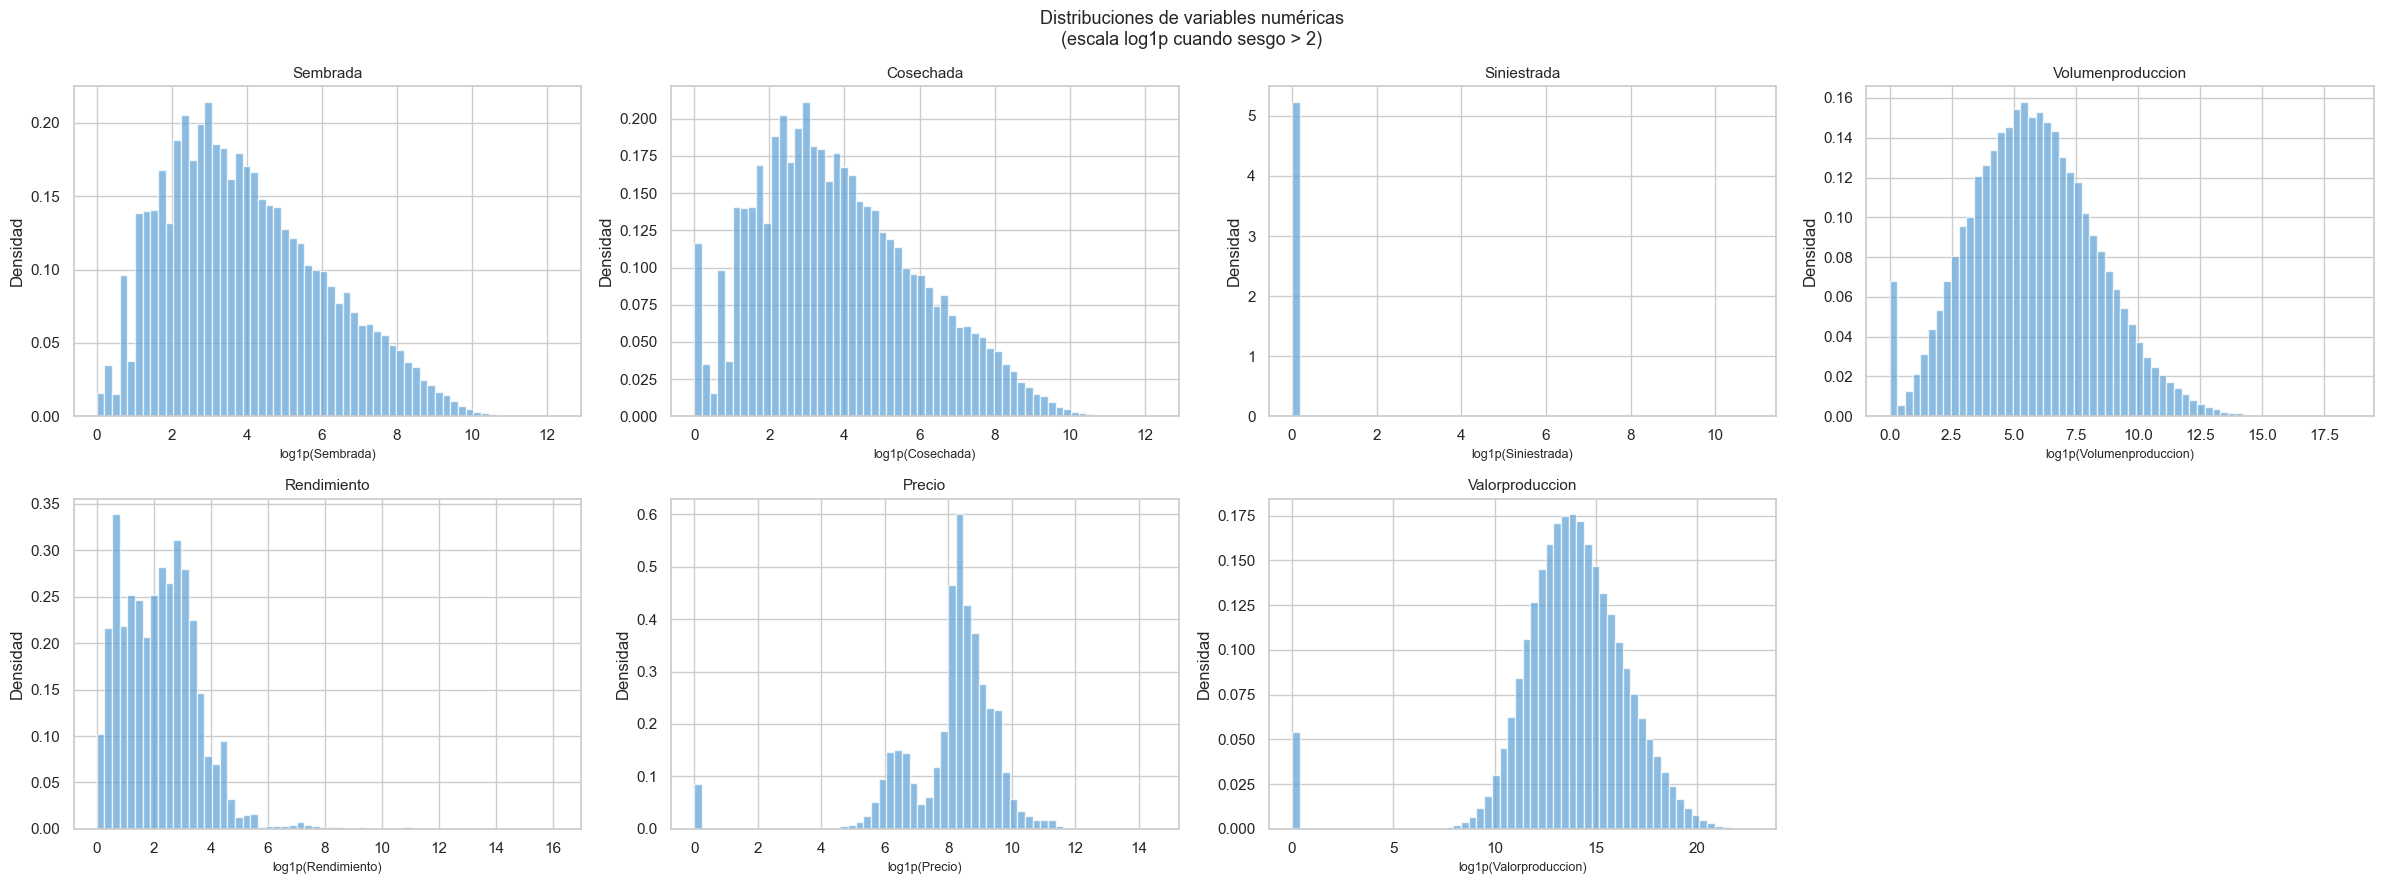

In [13]:
#| echo: false
eda.visualizar_distribuciones()

**Sembrada y Cosechada**

Ambas variables presentan distribuciones notablemente similares en forma, lo cual es coherente con su relación estructural: en condiciones normales, la mayor parte de lo sembrado termina siendo cosechado. La cola derecha corresponde a las grandes superficies comerciales identificadas en el análisis de outliers.

La similitud entre ambas distribuciones confirma que el dataset no presenta inconsistencias estructurales entre área sembrada y cosechada, y que la diferencia entre ambas es un fenómeno minoritario pero presente a lo largo de todo el rango de escala productiva.

**Siniestrada**

La gran mayoría de los registros no reportan pérdida alguna. Esta forma de distribución tiene implicaciones directas para el modelado. Un modelo de regresión convencional tendrá dificultades para ajustarse correctamente a esta estructura, ya que intentará predecir un valor continuo en una distribución donde el 75% de las observaciones son exactamente cero. Esto refuerza la decisión de plantear el problema supervisado como una clasificación binaria (siniestro / no siniestro) o, alternativamente, como un modelo en dos etapas: primero clasificar si habrá siniestro, y luego estimar su magnitud únicamente sobre los registros positivos.

**Volumen de Producción**

En escala `log1p`, Volumenproduccion presenta la distribución más cercana a una normal aproximada de todas las variables, con una concentración central en torno a log1p ≈ 7–8 (equivalente a volúmenes de 1,000–3,000 toneladas) y colas relativamente simétricas. Existe una pequeña masa en log1p = 0 que corresponde a registros sin producción (parcelas cosechadas con pérdida total o errores en la captura). La forma aproximadamente normal en escala logarítmica sugiere que el volumen de producción sigue una distribución log-normal.

**Rendimiento**

La distribución de Rendimiento en escala `log1p` es bimodal con sesgo positivo marcado. La primera moda aparece en valores muy bajos (log1p ≈ 0-1), y la segunda en log1p ≈ 3–4. Más preocupante es la cola extremadamente larga que se extiende hasta log1p ≈ 16, correspondiente a los valores de rendimiento en unidades no estándar identificados en el análisis de outliers. Esta bimodalidad puede estar reflejando dos poblaciones distintas dentro del mismo dataset: cultivos medidos en toneladas por hectárea y cultivos medidos en otras unidades, cuyos valores numéricos son órdenes de magnitud mayores.

**Precio**

Precio presenta la distribución más claramente bimodal del conjunto, con una primera concentración pequeña en valores bajos (log1p ≈ 6-7) y una segunda concentración principal y pronunciada en log1p ≈ 8–9 (equivalente a precios de 3,000–8,000 pesos por tonelada). Esta bimodalidad refleja la coexistencia de dos grupos de cultivos con estructuras de precio fundamentalmente distintas: por un lado, granos básicos de bajo precio unitario (maíz, sorgo, frijol) y por otro, productos hortícolas, frutícolas y especializados de alto valor comercial. La separación clara entre ambas modas sugiere que Precio podría ser una variable útil para capturar la diferencia entre agricultura de subsistencia y agricultura comercial.

**Valor de Producción**

Valorproduccion presenta en escala `log1p` la distribución más cercana a una campana simétrica, con la masa principal concentrada equivalente a valores de producción de entre 60,000 y 8,900,000 pesos por registro. Este rango representa la actividad económica agrícola típica a nivel municipal en México: desde pequeñas unidades productivas con ventas anuales de decenas de miles de pesos hasta operaciones medianas con ingresos de varios millones.

La barra de la izquierda corresponde a registros con valor de producción igual a cero, asociados principalmente a parcelas siniestradas en su totalidad donde no hubo cosecha que comercializar, o a registros con precio no disponible que impidieron el cálculo del valor.


## Relaciones entre variables

### Matriz de Correlaciones

Para analizar las relaciones entre las variables numéricas del dataset se calculó la matriz de correlaciones de Spearman, ya que mide la correlación entre los rangos de los valores en lugar de los valores directos, lo que la hace robusta ante distribuciones asimétricas y valores atípicos extremos como los identificados en las secciones anteriores. Dado que prácticamente todas las variables del dataset presentan sesgo positivo y outliers significativos, Spearman nos ayuda a capturar relaciones sin que los extremos distorsionen el resultado.

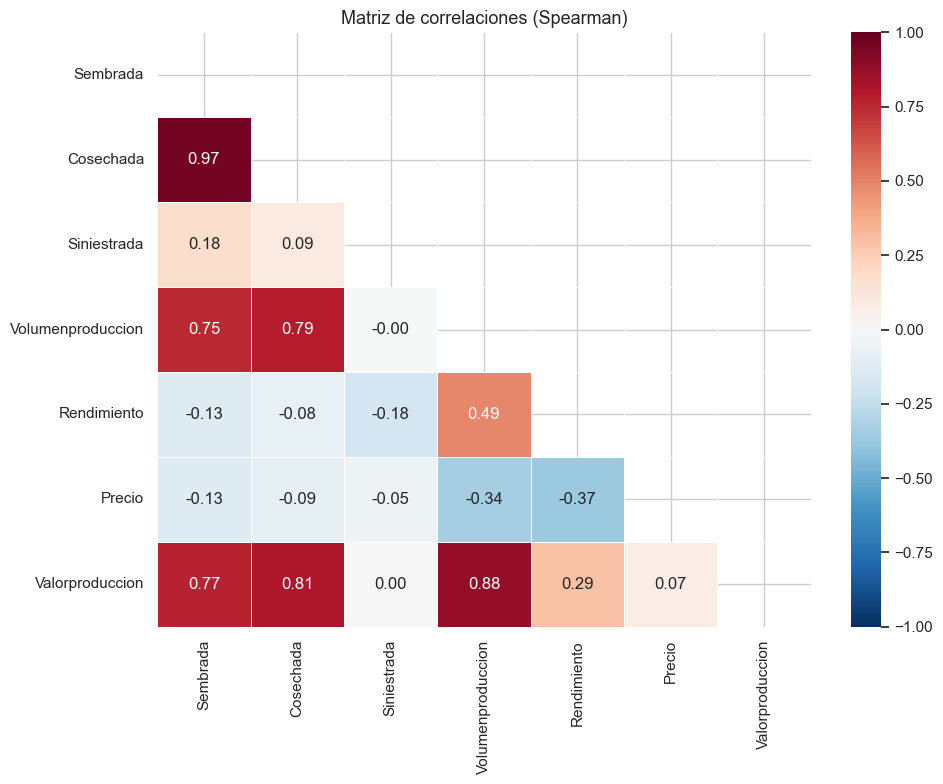

In [14]:
#| echo: false
corr = eda.matriz_correlaciones(metodo='spearman')

A partir del gráfico podemos realizar las siguientes observaciones relevantes:

- La correlación más alta del dataset, prácticamente perfecta, se da entre Sembrada y Cosechada. Esto nos indica que en la gran mayoría de los ciclos agrícolas, lo que se siembra termina siendo cosechado. La pequeña diferencia entre ambas variables es precisamente el espacio donde ocurre el siniestro.

- Las correlaciones positivas entre las variables de área (Sembrada y Cosechada) y el volumen de producción indican que a mayor superficie cosechada, mayor volumen producido. La correlación es ligeramente más fuerte con Cosechada (0.79) que con Sembrada (0.75), lo que tiene sentido porque el volumen de producción depende del área efectivamente cosechada, no del área inicialmente sembrada. Esta relación no es perfecta porque el rendimiento por hectárea varía considerablemente entre cultivos, regiones y años, introduciendo variabilidad que rompe la proporcionalidad directa.

- Un mayor rendimiento por hectárea se asocia con mayor volumen de producción, aunque la relación no es tan fuerte como cabría esperar porque el volumen también depende de la superficie cultivada. Municipios con rendimientos altos pero superficies pequeñas pueden tener volúmenes similares a municipios con rendimientos bajos pero grandes extensiones, esto debido al valor que tiene cada tipo de cultivo.

- Observamos correlaciones negativas moderadas para el Precio que revelan un patrón económico: los cultivos de mayor precio unitario tienden a producirse en menores volúmenes y con menores rendimientos en hectáreas. Los cultivos básicos de alto volumen como el maíz tienen precios bajos por tonelada, mientras que los productos como flores o especias tienen precios altos pero se producen en superficies pequeñas y con rendimientos acotados.

- El hallazgo más relevante para el objetivo del proyecto es que Siniestrada presenta correlaciones cercanas a cero con todas las demás variables. Ninguna variable numérica del dataset tiene una relación lineal con el área siniestrada. Esto puede indicar que el siniestro es un fenómeno multifactorial y no lineal.

### Área Sembrada y Área Siniestrada

La siguiente gráfica muestra la relación entre el área sembrada y el área siniestrada en escala `log1p` para una muestra aleatoria de 50,000 registros, diferenciando por modalidad hídrica.

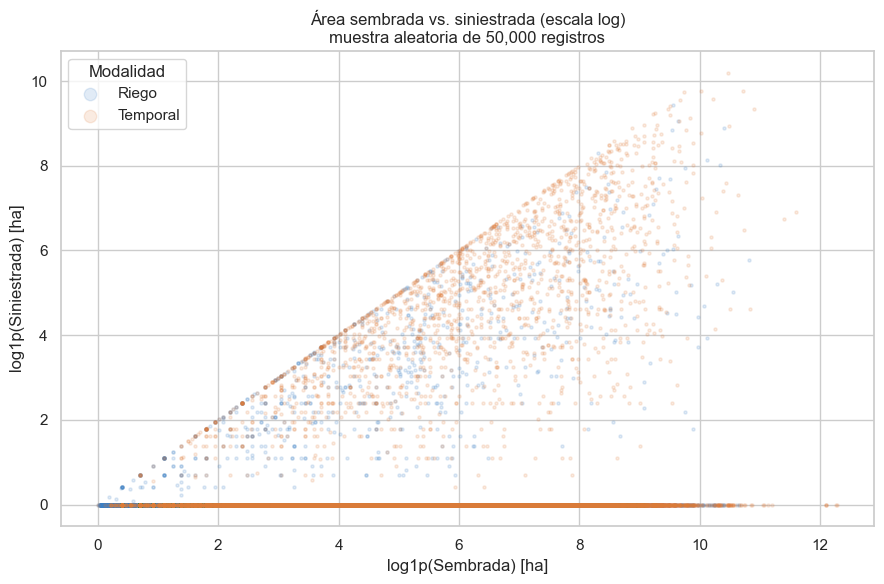

In [15]:
#| echo: false
eda.scatter_sembrada_vs_siniestrada()

El rasgo más dominante de la gráfica es la línea horizontal densa que se extiende a lo largo de todo el rango del eje horizontal. Esta línea representa todos los registros donde no hubo siniestro alguno, independientemente de la superficie sembrada. La gran mayoría de las siembras concluyen sin pérdida, sin importar si son de temporal o de riego ni cuál sea su escala.

Los registros con siniestro distinto de cero forman una nube de puntos delimitada por una diagonal superior que representa el límite físico del problema, que es que el área siniestrada no puede superar el área sembrada. Los puntos que se acercan a la diagonal son registros donde prácticamente la totalidad de lo sembrado se perdió, es decir, siniestros totales o casi totales. Los puntos en la parte inferior del triángulo representan siniestros parciales, donde solo una fracción del área sembrada se vio afectada.

Dentro de la nube de siniestros, se observa que la modalidad temporal alcanzan valores más altos en el eje vertical que la de riego. Los puntos de Riego también alcanzan valores altos pero con menor frecuencia en los extremos superiores. Esto puede indicar que la agricultura de modalidad temporal es estructuralmente más vulnerable al siniestro que la de riego, tanto en frecuencia como en magnitud de la pérdida. La dependencia de las lluvias en el temporal lo expone directamente a sequías, heladas e inundaciones, mientras que la infraestructura hídrica del riego actúa como amortiguador ante estas variaciones climáticas.

## Análisis de variables categóricas

Dentro de las variables categóricas encontramos: "Nomestado", "Nomcicloproductivo", "Nommodalidad", "Nomcultivo". A continuación se presentan los gráficos de las frecuencias en las categorías para cada una de estas variables.

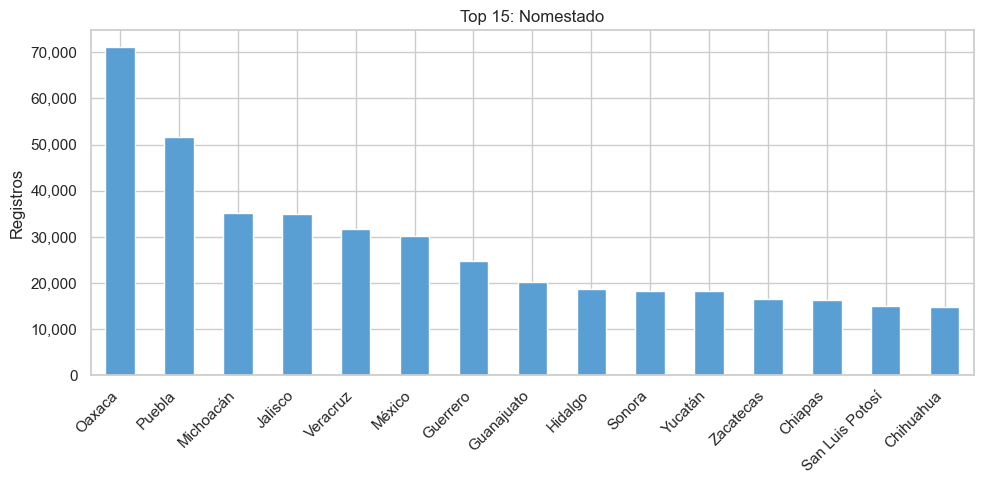

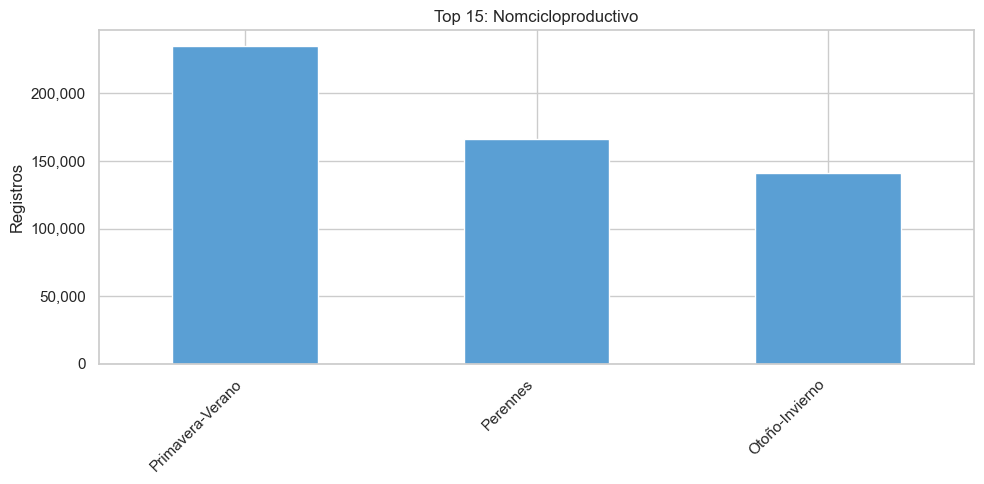

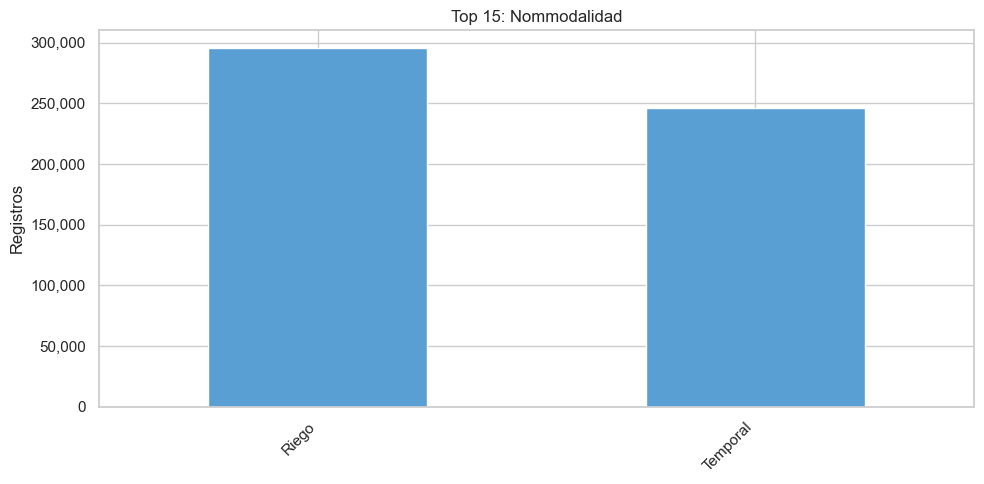

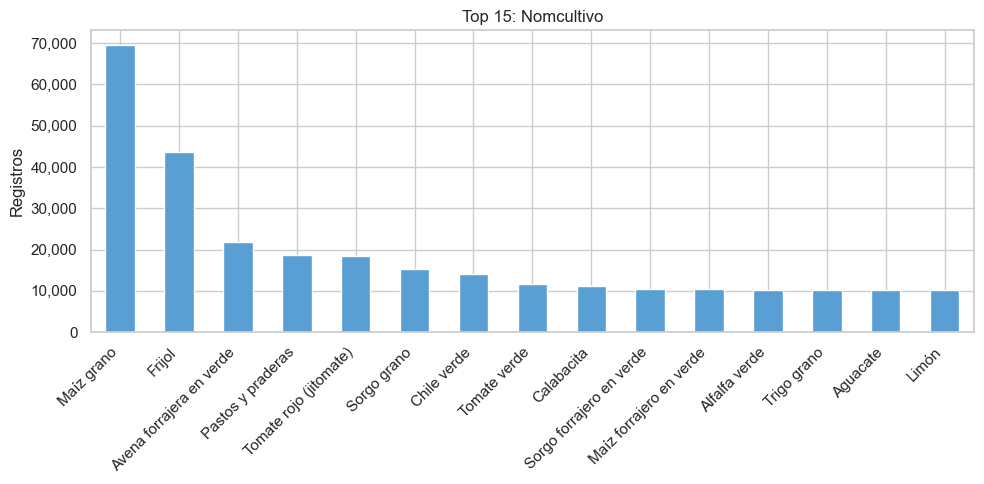

In [16]:
#| echo: false
eda.analisis_categoricas(top_n=15)

### Variable Estado

En la distribución de registros por estado Oaxaca encabeza el ranking con aproximadamente 70,000 registros. Oaxaca es el estado con mayor número de municipios en México, lo que multiplica directamente la cantidad de combinaciones posibles en el dataset. Además, su alta diversidad climática y cultural se traduce en una gran variedad de cultivos registrados, desde maíz y frijol en las sierras hasta café, cacao y frutas tropicales en las costas y valles. Su presencia dominante en el dataset no implica que sea el mayor productor en volumen o valor, sino el de mayor diversidad de registros agrícolas.

### Variable Ciclo Productivo

El dataset se distribuye entre tres ciclos agrícolas con frecuencias relativamente equilibradas, aunque Primavera-Verano es el predominante con aproximadamente 230,000 registros. Este ciclo concentra la mayor actividad agrícola del país porque coincide con la temporada de lluvias, que alimenta directamente la agricultura de temporal. La predominancia del ciclo Primavera-Verano es relevante para el análisis de siniestros porque es precisamente el ciclo más expuesto a fenómenos climáticos extremos como sequías e inundaciones durante la temporada de lluvias.

### Variable Modalidad Hídrica

La distribución entre Riego y Temporal es equilibrada, lo cual se explica porque la agricultura de riego, al permitir múltiples ciclos productivos al año y una mayor diversidad de cultivos, genera más combinaciones únicas de registro que la agricultura de temporal.

### Variable Cultivos

El ranking de cultivos confirma la centralidad del Maíz grano en la agricultura mexicana. Su presencia masiva refleja que se cultiva prácticamente en todos los estados, municipios, ciclos y modalidades del país, siendo el alimento base de la dieta mexicana y el cultivo de subsistencia. El Frijol ocupa el segundo lugar con cerca de 43,000 registros, consolidando junto al maíz el binomio tradicional de la milpa mexicana.

A partir del tercer lugar la frecuencia cae abruptamente: Avena forrajera en verde, Pastos y praderas y Tomate rojo (jitomate) rondan los 18,000–21,000 registros, seguidos por Sorgo grano, Chile verde, Tomate verde y Calabacita con entre 10,000 y 15,000 registros. La presencia de varios cultivos forrajeros (avena, pastos, sorgo forrajero, maíz forrajero, alfalfa) entre los más frecuentes refleja la importancia de la ganadería como actividad complementaria a la agricultura en muchas regiones del país.

### Cultivos más frecuentes en los Estados más frecuentes

El primer gráfico cruza los cinco estados con más registros en el dataset contra los cinco cultivos más frecuentes, permitiendo identificar qué combinaciones estado-cultivo dominan la estructura del dataset. El patrón más evidente es la concentración extrema en Oaxaca con maíz grano (17,757 registros) y frijol (11,919 registros). Estos dos valores por sí solos representan una proporción desproporcionada del total, lo que confirma que la combinación Oaxaca-maíz es el eje central alrededor del cual está construido el dataset.

Por otro lado, tenemos los registros por cultivo en los Top 5 estados. La barra azul de Oaxaca domina visualmente en maíz y frijol, duplicando o triplicando a cualquier otro estado en ambos cultivos. Esta asimetría visual refuerza el punto señalado anteriormente: el dataset tiene un sesgo estructural hacia Oaxaca en los cultivos básicos. Para los tres cultivos restantes la distribución entre estados es más equilibrada, con barras de altura similar entre Puebla, Michoacán, Jalisco y Veracruz.

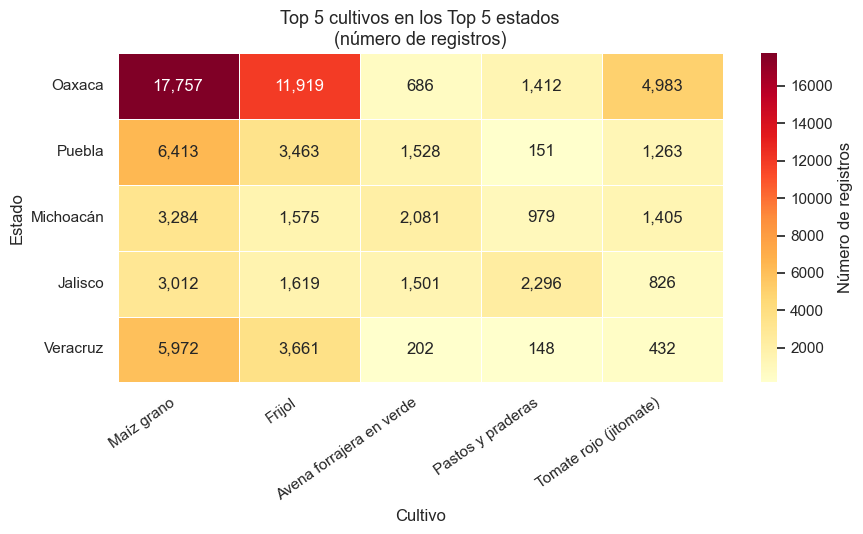

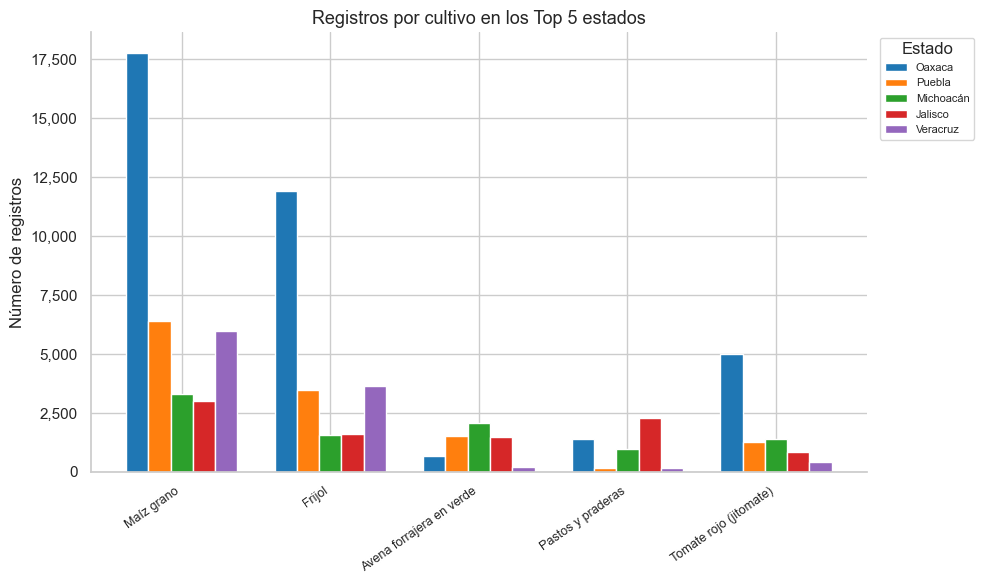

In [17]:
#| echo: false
pivot = eda.top_cultivos_por_estado()

## Serie de tiempo y análisis geográfico

### Cultivos a lo largo del tiempo

Las visualizaciones de series de tiempo permiten examinar la dimensión temporal del dataset, que abarca 15 años continuos de actividad agrícola (2010–2024). A diferencia de las secciones anteriores, que analizaron la distribución estática de las variables, esta sección busca identificar tendencias, ciclos y eventos atípicos en el comportamiento del sistema agrícola mexicano a lo largo del tiempo. La perspectiva temporal es fundamental para el objetivo del proyecto porque el riesgo de siniestro no es un fenómeno estático: está determinado en parte por condiciones climáticas que varían año con año y que han mostrado una tendencia de intensificación asociada al cambio climático.

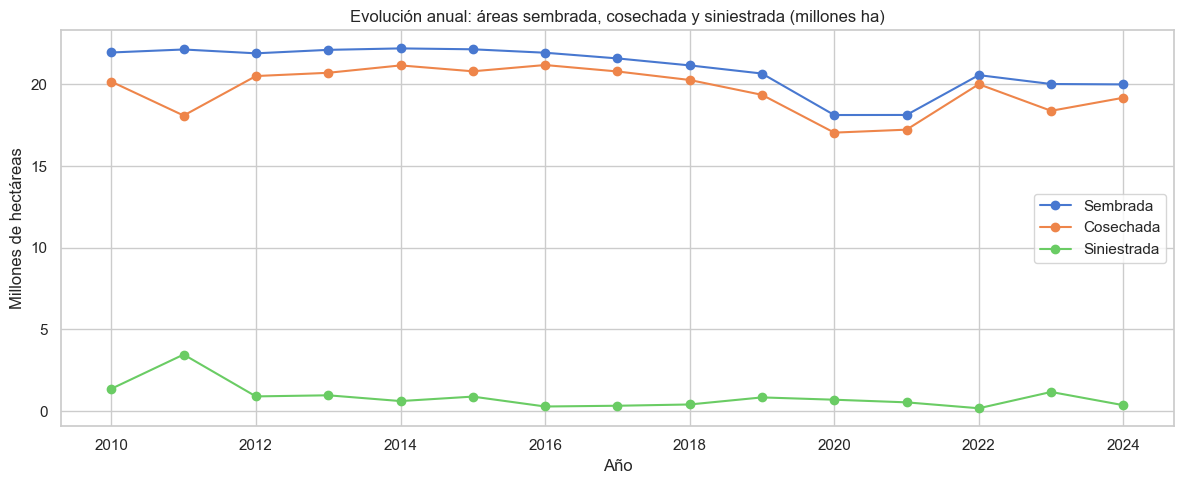

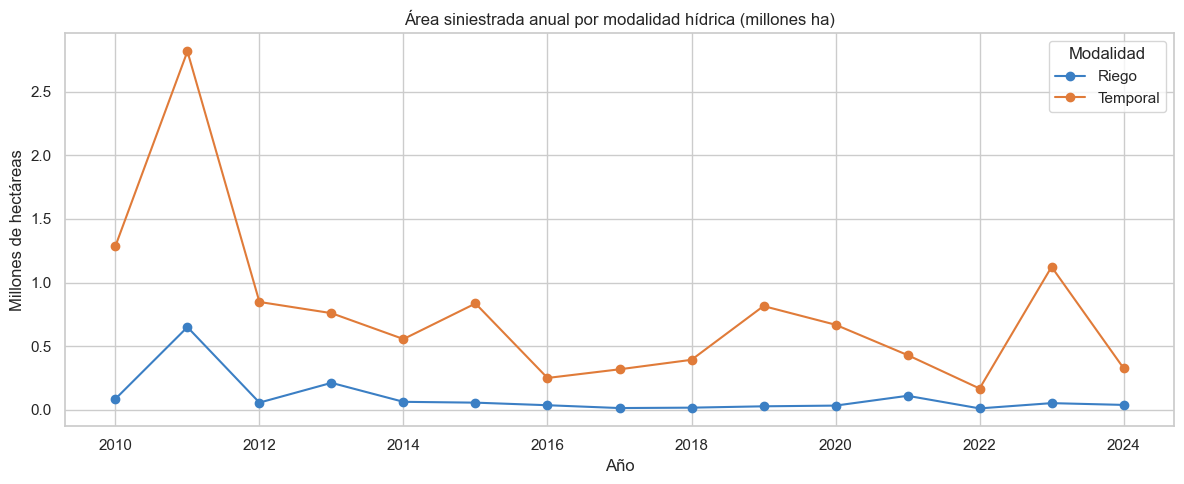

In [18]:
#| echo: false
anual = eda.serie_temporal()

**Evolución Anual**

La primera gráfica muestra la evolución de las tres variables de área a nivel nacional en millones de hectáreas para el periodo 2010–2024.

Área sembrada y cosechada muestran un comportamiento relativamente estable durante la primera mitad del periodo. A partir de 2019 se observa una caída pronunciada y sostenida que lleva ambas variables a su mínimo histórico en 2020–2021, con aproximadamente 18 millones de hectáreas sembradas y 17 millones cosechadas. Esta caída coincide con el periodo de pandemia por COVID-19, que afectó severamente las cadenas de suministro agrícola, el acceso a insumos y la disponibilidad de mano de obra en el campo mexicano. A partir de 2022 se observa una recuperación gradual, aunque sin recuperar los niveles máximos previos a 2019. La brecha persistente entre Sembrada y Cosechada a lo largo de todo el periodo refleja la pérdida estructural que ocurre en cada ciclo, compuesta tanto por siniestros como por abandono de parcelas y otros factores no climáticos.

El año de mayor siniestro en todo el periodo es 2011. Este año es ampliamente documentado como uno de los más severos en términos de sequía en México: la sequía de 2011 fue considerada la peor en décadas. Tras este pico, el área siniestrada cae drásticamente en 2012 y se mantiene en niveles bajos durante la mayor parte del resto del periodo, con un repunte moderado en 2023 que sugiere un nuevo episodio de condiciones climáticas adversas.

**Área Siniestrada Anual por Modalidad Hídrica**

En el segundo gráfico podemos observar como la modalidad Temporal domina completamente el siniestro en todos los años del periodo. En 2011, su pico más alto representa más de cuatro veces el valor de riego en ese mismo año. Esta diferencia es muestra que cuando ocurre una sequía severa, son las parcelas que dependen exclusivamente de la lluvia las que sufren las pérdidas más devastadoras, mientras que las de riego cuentan con infraestructura hídrica que mitiga parcialmente el impacto. 

La modalidad Riego presenta una línea considerablemente más baja y estable a lo largo de todo el periodo. Si bien el riego no es inmune al siniestro, su exposición al riesgo climático es significativamente menor.

### Área Siniestrada por Estado

El ranking revela que el riesgo agrícola en México tiene una geografía claramente definida hacia el **norte y el Altiplano Central**. San Luis Potosí y Zacatecas encabezan la lista con 1.75 y 1.6 millones de hectáreas perdidas acumuladas, seguidos por Tamaulipas (1.3 millones) y Sinaloa (1.05 millones). Los cuatro estados del top tienen en común grandes superficies de temporal expuestas a sequías recurrentes, y concentran prácticamente el doble de siniestro que cualquier estado del tercio inferior del ranking.

En contraste, estados como Oaxaca, Puebla o Jalisco (que lideraban el número de registros totales en el dataset) aparecen aquí con valores relativamente bajos, confirmando que tener muchos registros no equivale a tener alto riesgo.

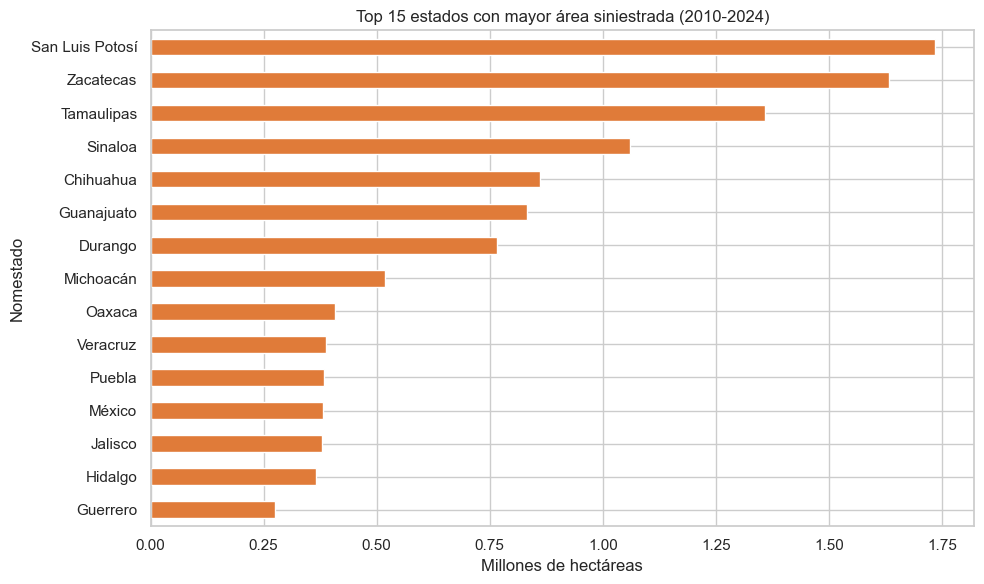

In [19]:
#| echo: false
ranking_estados = eda.top_estados_siniestros(top_n=15)

### Estados con Mayor Área Cosechada por Modalidad Hídrica

El siguiente gráfico muestra la superficie cosechada acumulada (2010–2024) por modalidad hídrica para los diez estados más productivos, permitiendo identificar tanto el volumen total como la composición interna de cada entidad.

Jalisco, Veracruz y Chiapas encabezan el ranking y los tres presentan una composición dominada por la modalidad temporal. Esto refleja que su alta productividad está sostenida principalmente por la agricultura dependiente de lluvias, lo que implica una exposición estructural al riesgo climático pese a no aparecer en el top de siniestros por sus condiciones climáticas relativamente favorables

En Sinaloa, vemos como la porción de riego supera ampliamente al temporal. Los grandes distritos de riego del norte sustentan una producción comercial intensiva de trigo, maíz, soya y hortalizas de exportación, por lo que presenta mayores avances hidroagrícolas.

Podemos ver que a pesar de que Oaxaca es el estado con más registros, no es el que tiene mayor área cosechada, sin embargo, su presencia en el ranking muestra su importancia en su aporte a la agricultura del país. Presenta casi la totalidad de su superficie cosechada bajo modalidad temporal, con una porción de riego mínima, lo que es coherente con su perfil de agricultura campesina de pequeña escala en zonas de difícil acceso donde la infraestructura hídrica es escasa.

Los estados con temporal casi exclusivo pero condiciones climáticas favorables (Jalisco, Veracruz, Chiapas, Oaxaca) cosechan mucho sin perder proporcionalmente, validando que la modalidad hídrica interactúa con la geografía climática para determinar el riesgo real.

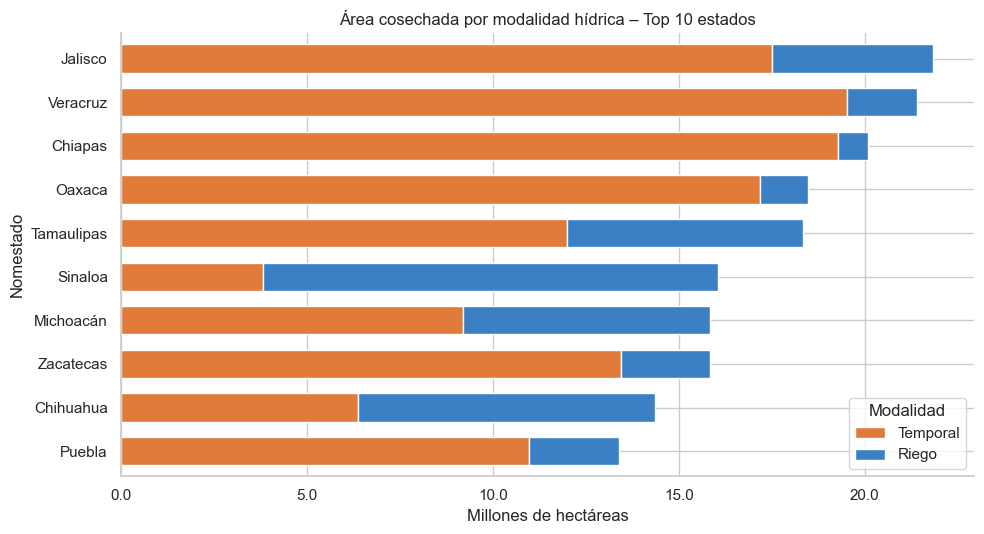

In [20]:
#| echo: false
tabla = eda.top_estados_cosechada()

## Resumen

**Calidad y estructura del dataset**

El conjunto de datos del SIAP para el período 2010–2024 cuenta con 541,839 registros y 24 variables, presentando una calidad de datos notablemente alta para una fuente de información pública. Los valores faltantes son mínimos: únicamente Precio y Rendimiento reportan nulos en 487 registros (0.09% del total), los cuales fueron identificados como ausencias estructurales asociadas a registros con área cosechada igual a cero, es decir, no hubo producción y por tanto no existe precio ni rendimiento que reportar. Los registros duplicados (10 en total) son insignificantes y no representan un problema para el análisis.

**Distribución geográfica**

La distribución de registros por estado revela una concentración notable en Oaxaca (71,184 registros), seguido de Puebla (51,753) y Michoacán (35,188). Esta concentración no refleja necesariamente mayor producción, sino mayor diversidad de registros, lo cual está directamente relacionado con que Oaxaca es el estado con más municipios en México (570). Esto es relevante porque implica que los modelos predictivos tendrán mayor información histórica para ciertos estados que para otros.

**Estacionalidad y modalidad hídrica**

El ciclo Primavera-Verano domina el dataset con 234,707 registros, lo que refleja la estructura estacional de la agricultura mexicana basada en lluvias. La modalidad Riego supera ligeramente a Temporal en número de registros (295,546 vs. 246,283), lo que podría explicarse por la mayor diversidad de cultivos que se pueden producir bajo riego y su extensión en más municipios a lo largo del año.

**Cultivos predominantes**

Maíz grano es el cultivo más frecuente con 69,586 registros, seguido de Frijol (43,677) y Avena forrajera en verde (21,910). Esta dominancia es consistente con el rol estratégico del maíz en la seguridad alimentaria nacional y su extensión geográfica en prácticamente todos los estados del país. La variable Nomcultivo presenta una cardinalidad muy alta (454 categorías), lo que implicará tratamiento especial en la fase de modelado.

**Nivel de riesgo y desbalance de clases**

La discretización de proporcion_siniestro en cinco niveles de riesgo revela un desbalance de clases importante: la categoría "Sin siniestro" es ampliamente mayoritaria.

In [21]:
#| echo: false
#| output: false

# Exportar como CSV (data/processed/siap_procesado.csv)
ruta = eda.exportar_dataset_limpio()


Dataset exportado correctamente.
  Ruta    : D:\PROYECTO MINERIA\Proyecto-Mineria-Datos\data\processed\siap_procesado.csv
  Formato : CSV
  Filas   : 541,829
  Columnas: 26
  Variables derivadas incluidas: proporcion_siniestro, nivel_riesgo
